# Import Libraries

In [1]:
library(tidyverse)
library(MASS)
library(CASDatasets)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'MASS'


The following object is masked from 'package:dplyr':

    select




### 1. Load Data: norauto

In [3]:
load("norauto.rda")

In [4]:
head(norauto)

,Male,Young,DistLimit,GeoRegion,Expo,ClaimAmount,NbClaim
,<int>,<int>,<fct>,<fct>,<dbl>,<dbl>,<int>
1,0,0,12000 km,Low+,0.789,0,0
2,0,1,12000 km,Medium+,0.200,0,0
3,0,1,25000-30000 km,Medium+,0.285,0,0
4,0,0,12000 km,Medium-,0.247,0,0
5,0,0,12000 km,High-,0.995,18158,1
6,0,0,12000 km,Medium+,0.222,0,0


In [5]:
str(norauto)

'data.frame':	183999 obs. of  7 variables:
 $ Male       : int  0 0 0 0 0 0 0 0 0 0 ...
 $ Young      : int  0 1 1 0 0 0 0 1 0 1 ...
 $ DistLimit  : Factor w/ 6 levels "12000 km","16000 km",..: 1 1 4 1 1 1 1 1 1 1 ...
 $ GeoRegion  : Factor w/ 6 levels "High-","High+",..: 4 6 6 5 1 6 4 1 1 4 ...
 $ Expo       : num  0.789 0.2 0.285 0.247 0.995 0.222 0.794 0.146 0.674 0.663 ...
 $ ClaimAmount: num  0 0 0 0 18158 ...
 $ NbClaim    : int  0 0 0 0 1 0 1 0 0 0 ...


In [8]:
norauto %>% dplyr::select(where(is.factor)) %>% lapply(levels)

$DistLimit
[1] "12000 km"       "16000 km"       "20000 km"       "25000-30000 km"
[5] "8000 km"        "no limit"      

$GeoRegion
[1] "High-"   "High+"   "Low-"    "Low+"    "Medium-" "Medium+"

In [9]:
norauto %>% mutate(DistLimit = factor(DistLimit, levels = c("8000 km","12000 km","16000 km","20000 km","25000-30000 km","no limit")),
                   GeoRegion = factor(GeoRegion, levels = c("High+","High-","Medium+","Medium-","Low+","Low-"))) -> norauto

In [10]:
norauto %>% dplyr::select(where(is.factor)) %>% lapply(levels)

$DistLimit
[1] "8000 km"        "12000 km"       "16000 km"       "20000 km"      
[5] "25000-30000 km" "no limit"      

$GeoRegion
[1] "High+"   "High-"   "Medium+" "Medium-" "Low+"    "Low-"

### 2. EDA: Male, Young, DistLimit, GeoRegion

In [16]:
col.summary <- function(x, data = norauto) {
    for (i in 1:length(x)) {
        data %>% group_by(.data[[x[i]]]) %>% summarise(n= n(), Freq = sum(NbClaim) / sum(Expo), Severity = sum(ClaimAmount * NbClaim) / sum(NbClaim)) %>% knitr::kable() %>% print()
    }
}

col.summary(colnames(norauto)[1:4], data = norauto)



| Male|      n|      Freq| Severity|
|----:|------:|---------:|--------:|
|    0|   4413| 0.1245455| 25590.61|
|    1| 179586| 0.0709470| 23486.82|


| Young|      n|      Freq| Severity|
|-----:|------:|---------:|--------:|
|     0| 139261| 0.0704557| 23577.89|
|     1|  44738| 0.0767749| 23500.45|


|DistLimit      |     n|      Freq| Severity|
|:--------------|-----:|---------:|--------:|
|8000 km        | 15264| 0.0456885| 23661.55|
|12000 km       | 34307| 0.0519030| 23729.45|
|16000 km       | 12969| 0.0576099| 23821.43|
|20000 km       | 37007| 0.0708489| 24879.83|
|25000-30000 km | 30763| 0.0791629| 23450.75|
|no limit       | 53689| 0.0954775| 22820.45|


|GeoRegion |     n|      Freq| Severity|
|:---------|-----:|---------:|--------:|
|High+     | 44212| 0.0838570| 23794.06|
|High-     | 55308| 0.0706177| 23280.66|
|Medium+   | 41493| 0.0683462| 23735.55|
|Medium-   | 25925| 0.0659052| 23744.19|
|Low+      | 14135| 0.0605998| 23626.41|
|Low-      |  2926| 0.0542841| 18624.

### Visuals of Frequency

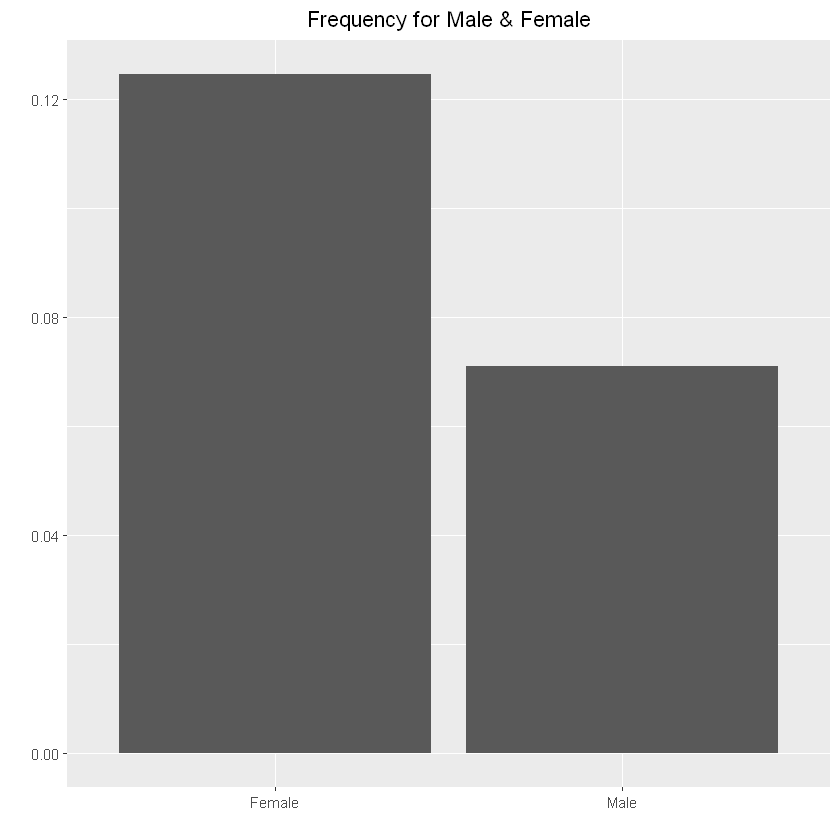

In [63]:
# Freq for Male 
norauto %>% 
    group_by(Male) %>% 
    summarise(Count = n(), Freq = sum(NbClaim) / sum(Expo)) %>% 
    ggplot(.) +
        geom_col(aes(x = factor(Male), y = Freq)) +
        labs(x = "", y = "", title = "Frequency for Male & Female") +
        scale_x_discrete(labels = c("Female", "Male")) +
        theme(plot.title = element_text(hjust = 0.5)) 

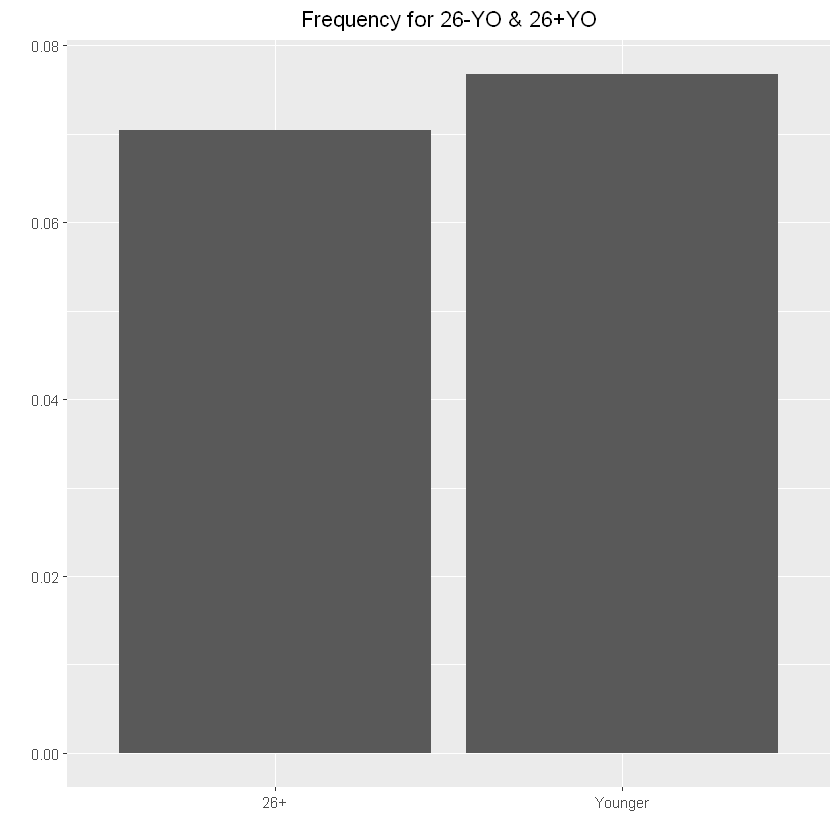

In [310]:
# Freq for Young 
norauto %>% 
    group_by(Young) %>% 
    summarise(Count = n(), Freq = sum(NbClaim) / sum(Expo)) %>% 
    ggplot(.) +
        geom_col(aes(x = factor(Young), y = Freq)) +
        labs(x = "", y = "", title = "Frequency for 26-YO & 26+YO") +
        scale_x_discrete(labels = c("26+", "Younger")) +
        theme(plot.title = element_text(hjust = 0.5))

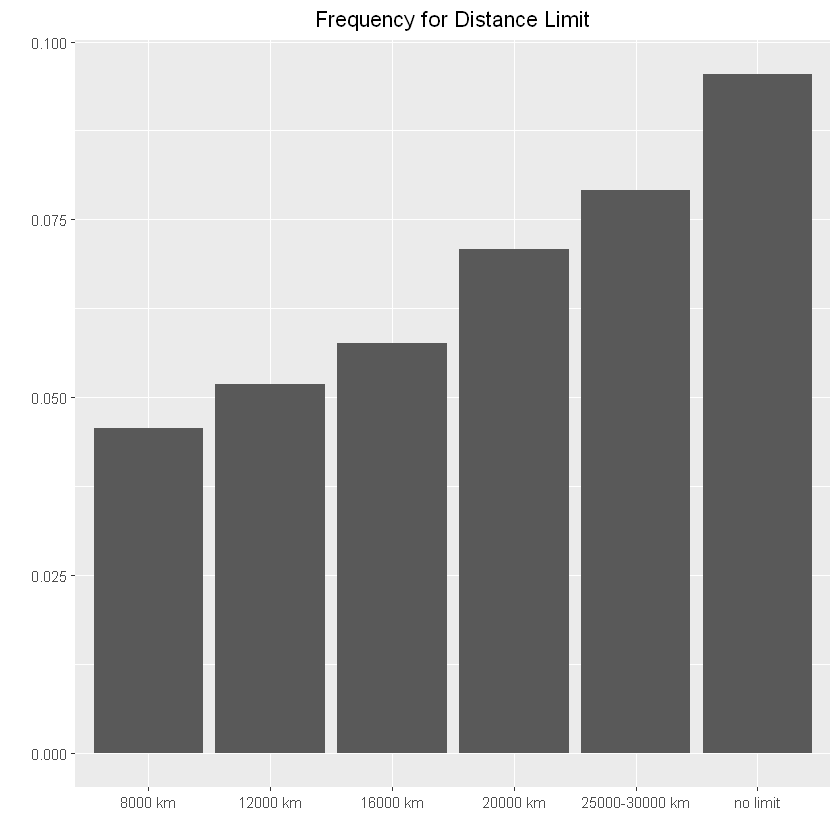

In [311]:
# Freq for distance limit 
norauto %>% 
    group_by(DistLimit) %>% 
    summarise(Count = n(), Freq = sum(NbClaim) / sum(Expo)) %>% 
    ggplot(.) +
        geom_col(aes(x = factor(DistLimit), y = Freq)) +
        labs(x = "", y = "", title = "Frequency for Distance Limit") +
        theme(plot.title = element_text(hjust = 0.5))

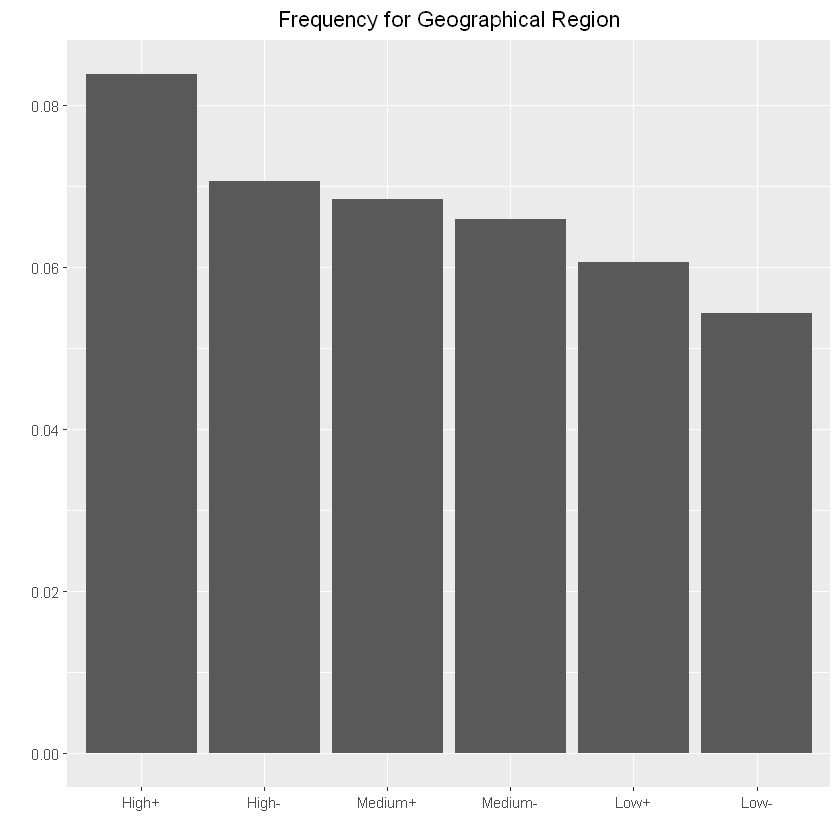

In [312]:
# Freq for geographical region 
norauto %>% 
    group_by(GeoRegion) %>% 
    summarise(Count = n(), Freq = sum(NbClaim) / sum(Expo)) %>% 
    ggplot(.) +
        geom_col(aes(x = factor(GeoRegion), y = Freq)) +
        labs(x = "", y = "", title = "Frequency for Geographical Region") +
        theme(plot.title = element_text(hjust = 0.5))

# Train data & Test Data

In [18]:
set.seed(999)
ind <- as.integer(sample(row.names(norauto), size = floor(0.2 * dim(norauto)[1])))
test_dt <- norauto[ind,]
train_dt <- norauto[- ind,]

In [19]:
cat(sprintf("Train Data: %d rows * %d columns", dim(train_dt)[1], dim(train_dt)[2]))

Train Data: 147200 rows * 7 columns

In [20]:
cat(sprintf("Test Data: %d rows * %d columns", dim(test_dt)[1], dim(test_dt)[2]))

Test Data: 36799 rows * 7 columns

# Frequency Modelling

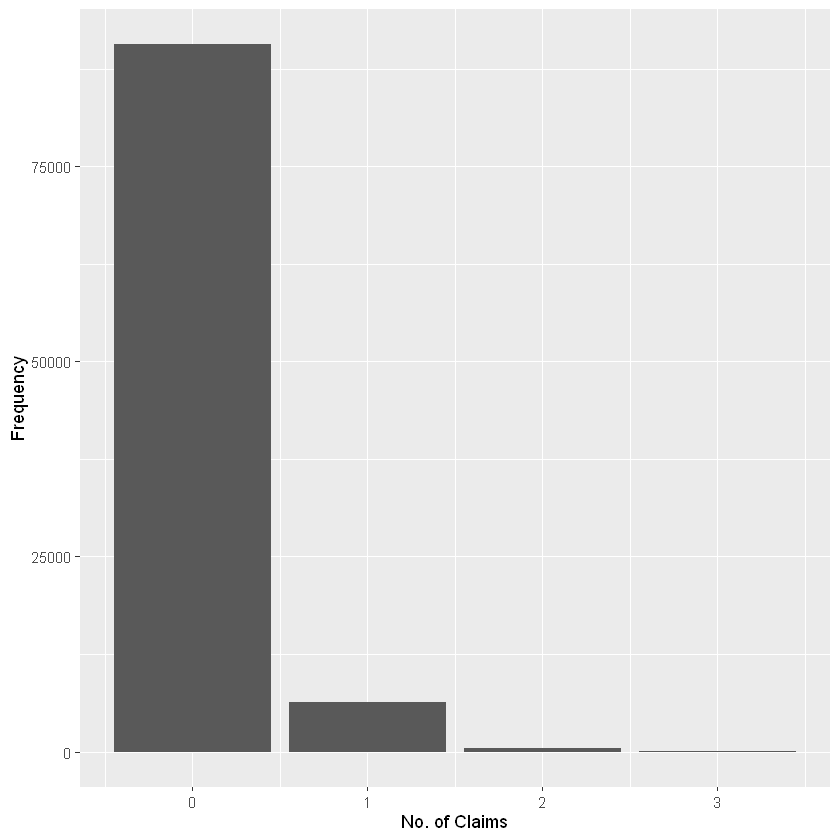

In [21]:
ggplot(data = train_dt) +
    geom_bar(aes(x = NbClaim, weight = Expo)) +
    labs(x = "No. of Claims", y = "Frequency")

### Poisson Distribution

In [22]:
freq.pois.full <- glm(NbClaim ~ Male + Young + DistLimit + GeoRegion, data = train_dt, offset = log(Expo), family = poisson(link = "log"))
summary(freq.pois.full)

# Dispersion parameter for poisson family taken to be 1 shows that Poisson distribution is a good fit.


Call:
glm(formula = NbClaim ~ Male + Young + DistLimit + GeoRegion, 
    family = poisson(link = "log"), data = train_dt, offset = log(Expo))

Coefficients:
                        Estimate Std. Error z value Pr(>|z|)    
(Intercept)             -2.39013    0.08230 -29.040  < 2e-16 ***
Male                    -0.60635    0.06463  -9.382  < 2e-16 ***
Young                    0.07151    0.02769   2.583  0.00980 ** 
DistLimit12000 km        0.18825    0.05778   3.258  0.00112 ** 
DistLimit16000 km        0.30576    0.06791   4.502 6.72e-06 ***
DistLimit20000 km        0.46943    0.05559   8.444  < 2e-16 ***
DistLimit25000-30000 km  0.59673    0.05644  10.572  < 2e-16 ***
DistLimitno limit        0.78980    0.05218  15.136  < 2e-16 ***
GeoRegionHigh-          -0.17464    0.03092  -5.648 1.63e-08 ***
GeoRegionMedium+        -0.24693    0.03447  -7.164 7.83e-13 ***
GeoRegionMedium-        -0.30361    0.04138  -7.337 2.19e-13 ***
GeoRegionLow+           -0.39362    0.05455  -7.215 5.39e-13 *

In [33]:
### Dispersion Checking: Pearson chi-sq Statistic

sum(residuals(freq.pois.full, "pearson")^2)/(freq.pois.full$df.residual)

[1] 0.9892021

### Negative Binomial

In [36]:
# find intial theta for before modelling
nb.model <- glm.nb(NbClaim ~ Male + Young + DistLimit + GeoRegion + offset(log(Expo)), data = train_dt, control = glm.control(maxit = 100))
(theta <- nb.model$theta)

[1] 46.61735

In [42]:
# init.theta is defined by the above theta estimate
freq.nb.full <- glm.nb(NbClaim ~ Male + Young + DistLimit + GeoRegion + offset(log(Expo)), data = train_dt, init.theta = theta, control = glm.control(maxit = 100))
summary(freq.nb.full)


Call:
glm.nb(formula = NbClaim ~ Male + Young + DistLimit + GeoRegion + 
    offset(log(Expo)), data = train_dt, control = glm.control(maxit = 100), 
    init.theta = 46.61735456, link = log)

Coefficients:
                        Estimate Std. Error z value Pr(>|z|)    
(Intercept)             -2.39029    0.08239 -29.012  < 2e-16 ***
Male                    -0.60638    0.06470  -9.372  < 2e-16 ***
Young                    0.07146    0.02771   2.579  0.00992 ** 
DistLimit12000 km        0.18844    0.05783   3.259  0.00112 ** 
DistLimit16000 km        0.30604    0.06797   4.502 6.72e-06 ***
DistLimit20000 km        0.46957    0.05564   8.439  < 2e-16 ***
DistLimit25000-30000 km  0.59689    0.05650  10.565  < 2e-16 ***
DistLimitno limit        0.78997    0.05223  15.125  < 2e-16 ***
GeoRegionHigh-          -0.17460    0.03095  -5.641 1.69e-08 ***
GeoRegionMedium+        -0.24696    0.03450  -7.158 8.16e-13 ***
GeoRegionMedium-        -0.30360    0.04141  -7.331 2.29e-13 ***
GeoRegionLow

In [43]:
### Dispersion Checking: Pearson chi-sq Statistic
sum(residuals(freq.nb.full, "pearson")^2)/(freq.nb.full$df.residual)

[1] 0.9881986

### AIC & Dispersion for Model Selction

In [40]:
AIC(freq.pois.full, freq.nb.full) %>% 
    arrange(AIC) %>% 
    rownames_to_column(var = "Model") %>% 
    mutate("Dispersion" = c(sum(residuals(freq.pois.full, "pearson")^2)/(freq.pois.full$df.residual), sum(residuals(freq.nb.full, "pearson")^2)/(freq.nb.full$df.residual)))

# Smaller AIC and dispersion closer to 1 for Poisson Full model

Model,df,AIC,Dispersion
<chr>,<dbl>,<dbl>,<dbl>
freq.pois.full,13,53082.03,0.9892021
freq.nb.full,14,53083.90,0.9881986


# Severity Modelling

### Severity Data Preparation

In [45]:
sev_train <- train_dt %>% filter(ClaimAmount > 0)
sev_test <- test_dt %>% filter(ClaimAmount > 0)

### Gamma

In [46]:
sev.gamma.full <- glm(ClaimAmount ~ Male * Young + GeoRegion + DistLimit, data = sev_train, family = Gamma(link = "log"))
summary(sev.gamma.full)


Call:
glm(formula = ClaimAmount ~ Male * Young + GeoRegion + DistLimit, 
    family = Gamma(link = "log"), data = sev_train)

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)             10.237604   0.114440  89.458   <2e-16 ***
Male                    -0.160920   0.095250  -1.689   0.0912 .  
Young                   -0.297674   0.182916  -1.627   0.1037    
GeoRegionHigh-           0.014936   0.039454   0.379   0.7050    
GeoRegionMedium+         0.020433   0.043917   0.465   0.6418    
GeoRegionMedium-         0.030351   0.052474   0.578   0.5630    
GeoRegionLow+            0.011291   0.068895   0.164   0.8698    
GeoRegionLow-           -0.137261   0.155175  -0.885   0.3764    
DistLimit12000 km       -0.002039   0.073329  -0.028   0.9778    
DistLimit16000 km       -0.053656   0.086237  -0.622   0.5338    
DistLimit20000 km        0.062978   0.070672   0.891   0.3729    
DistLimit25000-30000 km -0.022498   0.071799  -0.313   0.7540    
D

### Log Normal

In [47]:
sev.ln.full <- glm(log(ClaimAmount) ~ Male * Young + GeoRegion + DistLimit, data = sev_train)
summary(sev.ln.full)


Call:
glm(formula = log(ClaimAmount) ~ Male * Young + GeoRegion + DistLimit, 
    data = sev_train)

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)              9.621274   0.112895  85.224   <2e-16 ***
Male                    -0.056023   0.093964  -0.596    0.551    
Young                   -0.082847   0.180446  -0.459    0.646    
GeoRegionHigh-           0.002583   0.038921   0.066    0.947    
GeoRegionMedium+        -0.008759   0.043324  -0.202    0.840    
GeoRegionMedium-        -0.002173   0.051766  -0.042    0.967    
GeoRegionLow+           -0.060179   0.067965  -0.885    0.376    
GeoRegionLow-           -0.131530   0.153079  -0.859    0.390    
DistLimit12000 km       -0.003065   0.072339  -0.042    0.966    
DistLimit16000 km       -0.002141   0.085072  -0.025    0.980    
DistLimit20000 km        0.016899   0.069717   0.242    0.808    
DistLimit25000-30000 km -0.016735   0.070829  -0.236    0.813    
DistLimitno limit       -0

In [48]:
pred.Gamma <- predict.glm(sev.gamma.full, newdata = sev_test, type = "response")
pred.LogNormal <- exp(predict.glm(sev.ln.full, newdata = sev_test, type = "response"))

In [49]:
tibble(pred.Gamma, pred.LogNormal, y = sev_test$ClaimAmount) %>% 
    summarise(MSE.Gamma = mean((pred.Gamma - y)^2), MSE.LogNormal = mean((pred.LogNormal - y)^2)) %>%
    t() %>% as.data.frame() %>% 
    rownames_to_column() %>% 
    rename(Model = rowname, MSE = V1) %>% 
    arrange(MSE)

## Gamma distribution has lower MSE

Model,MSE
<chr>,<dbl>
MSE.Gamma,531290546
MSE.LogNormal,596055267


In [61]:
tibble(pred.Gamma, pred.LogNormal, y = sev_test$ClaimAmount) %>% head(5)

pred.Gamma,pred.LogNormal,y
<dbl>,<dbl>,<dbl>
23732.97,13901.56,58425
22999.77,13891.93,11400
25714.40,15001.48,8139
23229.00,13983.72,13307
24095.74,14704.97,20018


# Pure Premium

### Quick Review of Predictions on Test data

In [50]:
# prediction of frequency
summary(predict.glm(freq.pois.full, newdata= test_dt, type="response"))

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.003002 0.020934 0.039148 0.047456 0.064057 0.983648 

In [51]:
tibble(Freq = predict.glm(freq.pois.full, newdata= test_dt, type="response"),
       Severity = predict.glm(sev.gamma.full, newdata= test_dt, type="response"),
       ClaimAmount = test_dt$ClaimAmount,
       NbClaim = test_dt$NbClaim,
       Expo = test_dt$Expo) -> pred_dt

In [52]:
summary(pred_dt)

      Freq             Severity      ClaimAmount        NbClaim      
 Min.   :0.003002   Min.   :17133   Min.   :     0   Min.   :0.0000  
 1st Qu.:0.020934   1st Qu.:23000   1st Qu.:     0   1st Qu.:0.0000  
 Median :0.039148   Median :23734   Median :     0   Median :0.0000  
 Mean   :0.047456   Mean   :23976   Mean   :  1066   Mean   :0.0491  
 3rd Qu.:0.064057   3rd Qu.:24465   3rd Qu.:     0   3rd Qu.:0.0000  
 Max.   :0.983648   Max.   :30667   Max.   :194497   Max.   :2.0000  
      Expo        
 Min.   : 0.1010  
 1st Qu.: 0.3100  
 Median : 0.5750  
 Mean   : 0.6634  
 3rd Qu.: 1.0000  
 Max.   :12.6250  

In [56]:
pred_dt %>% 
    mutate(pure_premium = Freq * Severity) %>%
    summarise(N = n(), 
              MeanFreq = mean(Freq), 
              MeanSev = mean(Severity), 
              MeanPremium = mean(pure_premium),
              PredictedLoss = N * MeanPremium,
              ObservedLoss = sum(Severity*NbClaim),
              `Pred/Observed` = PredictedLoss / ObservedLoss) -> summary_tbl

summary_tbl

N,MeanFreq,MeanSev,MeanPremium,PredictedLoss,ObservedLoss,Pred/Observed
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
36799,0.047456,23976.05,1133.305,41704501,43121018,0.9671502


In [79]:
summary_tbl %>% dplyr::select(PredictedLoss, ObservedLoss, `Pred/Observed`)

PredictedLoss,ObservedLoss,Pred/Observed
<dbl>,<dbl>,<dbl>
41704501,43121018,0.9671502


# Gross Premium

### Permissible Loss Ratio

In [81]:
# permissible_loss_ratio: variable expense ratio plus profit margin
permissible_loss_ratio <- 0.7

# gross premium 
(gross_premium <- summary_tbl$MeanPremium / permissible_loss_ratio)

[1] 1619.008

In [82]:
summary_tbl %>% mutate("GrossPremium" = gross_premium)

N,MeanFreq,MeanSev,MeanPremium,PredictedLoss,ObservedLoss,Pred/Observed,GrossPremium
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
36799,0.047456,23976.05,1133.305,41704501,43121018,0.9671502,1619.008
